# TMD A12B for specific eta

In [1]:
pip install -U pysr

  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 24.7 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 27.6 MB/s eta 0:00:00a 0:00:01
Using cached sympy-1.14.0-py3-none-any.whl (6.3 MB)
Using cached mpmath-1.3.0-py3-none-any.whl (536 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.4/20.4 MB 30.7 MB/s eta 0:00:00a 0:00:01
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
Note: you may need to restart the kernel to use updated packages.


Julia and Julia dependencies are installed at first import:

In [ ]:
import pysr

[juliapkg] Found dependencies: /Users/hariprashadravikumar/.julia/conda/3/aarch64/lib/python3.12/site-packages/juliapkg/juliapkg.json
[juliapkg] Found dependencies: /Users/hariprashadravikumar/.julia/conda/3/aarch64/lib/python3.12/site-packages/pysr/juliapkg.json
[juliapkg] Found dependencies: /Users/hariprashadravikumar/.julia/conda/3/aarch64/lib/python3.12/site-packages/juliacall/juliapkg.json
[juliapkg] Locating Julia ^1.10.3
[juliapkg] Using Julia 1.11.3 at /Users/hariprashadravikumar/.julia/juliaup/julia-1.11.3+0.aarch64.apple.darwin14/bin/julia
[juliapkg] Finding libjulia:
           | using Libdl
           | print(abspath(Libdl.dlpath("libjulia")))
[juliapkg] Using Julia project at /Users/hariprashadravikumar/.julia/conda/3/aarch64/julia_env
[juliapkg] Writing Project.toml:
           | [deps]
           | SymbolicRegression = "8254be44-1295-4e6a-a16d-46603ac705cb"
           | Serialization = "9e88b42a-f829-5b0c-bbe9-9e923198166b"
           | PythonCall = "6099a3de-0909-46bc-

    Updating registry at `~/.julia/registries/General.toml`
   Resolving package versions...
   Installed MicroMamba ─────────────── v0.1.15
   Installed pixi_jll ───────────────── v0.76.2+0
   Installed ScientificTypesBase ────── v3.1.0
   Installed DiffRules ──────────────── v1.16.0
   Installed Tricks ─────────────────── v0.1.13
   Installed Scratch ────────────────── v1.3.0
   Installed IrrationalConstants ────── v0.2.6
   Installed DynamicExpressions ─────── v1.10.4
   Installed Adapt ──────────────────── v4.7.0
   Installed OpenSSL_jll ────────────── v3.5.7+0
   Installed StatisticalTraits ──────── v3.5.0
   Installed JSON ───────────────────── v1.7.1
   Installed ADTypes ────────────────── v1.23.0
   Installed PythonCall ─────────────── v0.9.26
   Installed SpecialFunctions ───────── v2.9.0
   Installed Parsers ────────────────── v2.8.7
   Installed Tables ─────────────────── v1.13.0
   Installed micromamba_jll ─────────── v2.3.1+0
   Installed PtrArrays ──────────────── v1.4.0


Now, let's import everything else as well as the PySRRegressor:


In [ ]:
import sympy
import numpy as np
from matplotlib import pyplot as plt
from pysr import PySRRegressor
from sklearn.model_selection import train_test_split
import h5py

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


# PySR for A12B eta = 8:


In [ ]:

file_path = "/Users/hariprashadravikumar/sivers_TMD_PhD_project/save_h5_A12B_A2B/allPL_eta_bL_bT_mean_err_forReImAmps.h5"
P1 = 3
data_list = []
with h5py.File(file_path, "r") as h5_file:
    dataset_name = f"Pl-{P1}/eta_8_bL_bT_ReA12B_err" #typo in bL : this is not PL
    dataPl = np.array(h5_file[dataset_name])    
    data_list.append(dataPl)

data = np.vstack(data_list)

# Remove rows where bL=0 and bT=0
#mask =  ~((data[:, 2] >= -3) & (data[:, 2] <= 9))
#data = data[mask]

# Extract bLbT and A12B
bLbT = data[:, 1:3]  
A2B = data[:, 3]   
A2Berr = data[:, 4]
A2Bweight = [1/sigma**2 for sigma in A2Berr]


#print(data)
#print("A12B =", A12B)
#print("A12Berr =", A12Berr)

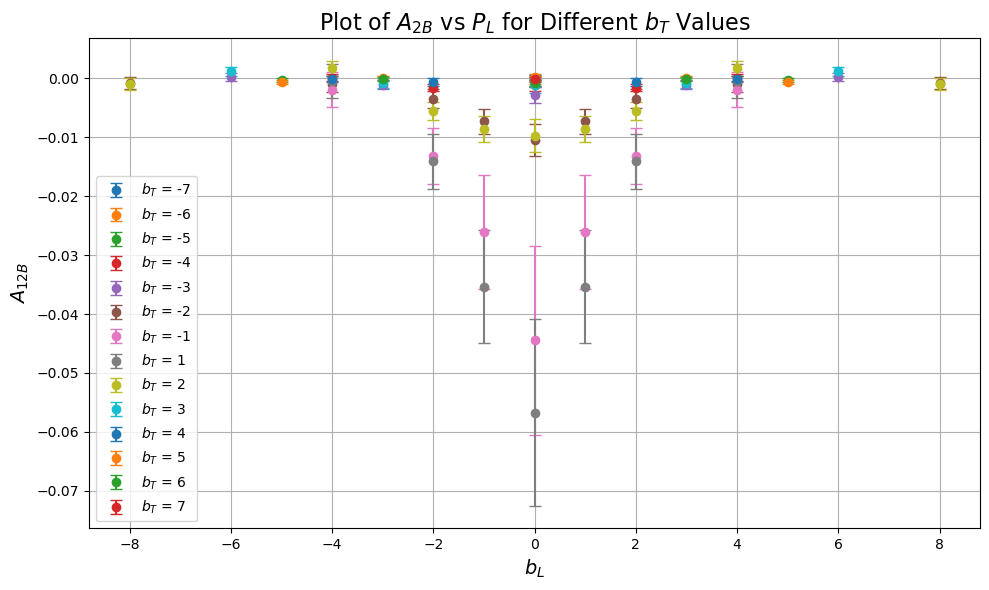

In [ ]:

# Extract unique bT values
unique_bT = np.unique(bLbT[:, 1])

# Create the plot
plt.figure(figsize=(10, 6))

for i, bT in enumerate(unique_bT):
    #if bT<1 :
    #    continue
    # Filter data for the current bT value
    mask = bLbT[:, 1] == bT
    bL_values = bLbT[mask, 0]
    A2B_values = A2B[mask]
    A2B_errors = A2Berr[mask]

    # Plot with error bars
    plt.errorbar(
        bL_values,
        A2B_values,
        yerr=A2B_errors,
        fmt='o',
        label=f"$b_T$ = {int(bT)}",
        capsize=4
    )
# Add labels, legend, and grid
plt.xlabel("$b_L$", fontsize=14)
plt.ylabel("$A_{12B}$", fontsize=14)
plt.title("Plot of $A_{2B}$ vs $P_L$ for Different $b_T$ Values", fontsize=16)
plt.legend(fontsize=10)
plt.grid(True)
plt.tight_layout()
plt.show()


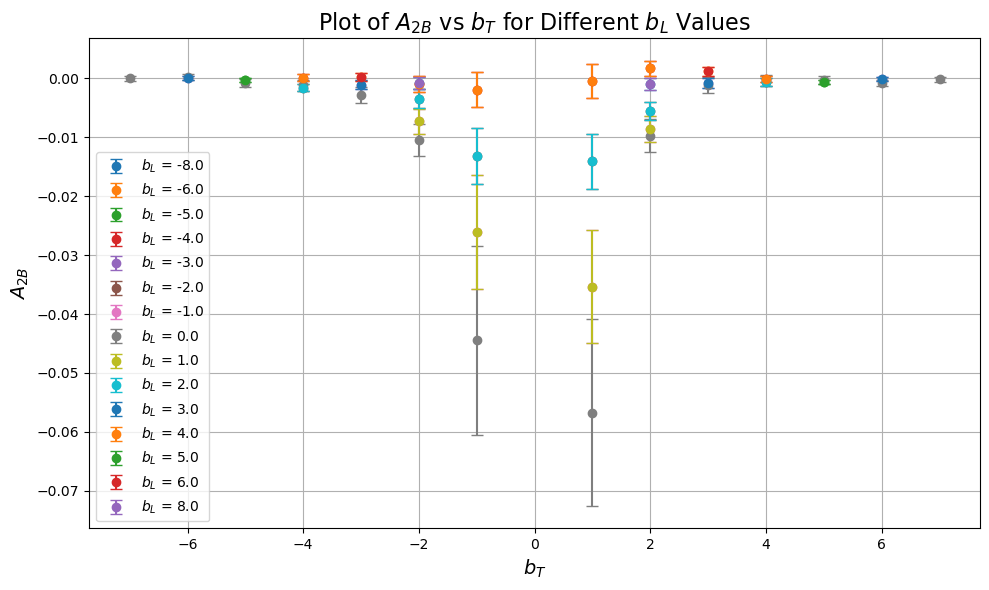

In [ ]:
# Extract unique bT values
unique_bL = np.unique(bLbT[:, 0])

# Create the plot
plt.figure(figsize=(10, 6))

for i, bL in enumerate(unique_bL):
    #if bT<1 :
    #    continue
    # Filter data for the current bT value
    mask = bLbT[:, 0] == bL
    bT_values = bLbT[mask, 1]
    A2B_values = A2B[mask]
    A2B_errors = A2Berr[mask]

    # Plot with error bars
    plt.errorbar(
        bT_values,
        A2B_values,
        yerr=A2B_errors,
        fmt='o',
        label=f"$b_L$ = {bL}",
        capsize=4
    )
# Add labels, legend, and grid
plt.xlabel("$b_T$", fontsize=14)
plt.ylabel("$A_{2B}$", fontsize=14)
plt.title("Plot of $A_{2B}$ vs $b_T$ for Different $b_L$ Values", fontsize=16)
plt.legend(fontsize=10)
plt.grid(True)
plt.tight_layout()
plt.show()


By default, we will set up 30 populations of expressions (which evolve independently except for migrations), use 4 threads, and use `"best"` for our model selection strategy:

In [ ]:
default_pysr_params = dict(
    populations=30,
    model_selection="best",
)

In [ ]:
from sympy import exp, sech, symbols, Function

custom_loss_function = """
using Symbolics

function eval_loss(tree, dataset::Dataset{T,L}, options)::L where {T,L}
    prediction, flag = eval_tree_array(tree, dataset.X, options)
    if !flag
        return L(Inf)
    end
    
    wmse = sum((prediction .- dataset.y).^2 .* dataset.weights) / (dataset.n - 3)
    return wmse
end
"""

extra_sympy_mappings = {
    "PowerLaw": lambda x, y: 1 / (y + x**1)
}



modelold = PySRRegressor(
    niterations=50,
    unary_operators=["exp", "sech"],
    binary_operators=["*", "PowerLaw(x, y) = 1/(y + x^1)", "^"],
    extra_sympy_mappings=extra_sympy_mappings,  # Include the custom mappings
    loss_function=custom_loss_function,  # Use the custom loss function
    nested_constraints = { "PowerLaw": {"PowerLaw": 0}},
    constraints={'^': (-1, 1), 'PowerLaw': (-1, 1)}

)

model = PySRRegressor(
    niterations=50,
    maxsize = 30,
    #unary_operators=["exp", "sin", "cos"],
    binary_operators=["*", "+", "-", "/", "^"],
    #extra_sympy_mappings=extra_sympy_mappings,  # Include the custom mappings
    loss_function=custom_loss_function,  # Use the custom loss function
    nested_constraints = { "^": {"^": 0, "+": 0},  "/": {"^": 0, "+": 0}},
    constraints={'^': (-1, 1)}

)


model.fit(bLbT, A2B, weights=A2Bweight, variable_names=['bL', 'bT'])



/opt/homebrew/anaconda3/lib/python3.11/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
[ Info: Started!
[ Info: Final population:
[ Info: Results saved to:



Expressions evaluated per second: 2.770e+05
Progress: 1455 / 1550 total iterations (93.871%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           1.454e+02  0.000e+00  y = 0.13667
5           1.445e+02  1.516e-03  y = (bL * -0.0023273) + 0.13747
7           6.846e+01  3.736e-01  y = -2.8222 / (-9.5635 - (bL * bL))
9           6.328e+01  3.935e-02  y = (-8.0232 / (-19.962 - (bL * bL))) + -0.11073
13          7.762e+00  5.246e-01  y = -3.0447 / (((bT / -1.9832) * bT) - ((bL * bL) - -4.493...
                                      7))
15          1.536e+00  8.101e-01  y = (-6.9037 / ((bT * (bT * -0.57339)) - ((bL * bL) - -10....
                                      051))) + -0.096048
17          9.666e-01  2.315e-01  y = (-7.0146 / ((bT * ((bT - -0.41671) * -0.57539)) - ((bL...
          

PySRRegressor.equations_ = [
	    pick     score                                           equation  \
	0         0.000000                                         0.13666837   
	1         0.001519                   (bL * -0.0023272585) + 0.1374651   
	2         0.373631               -2.8221543 / (-9.563522 - (bL * bL))   
	3         0.039356  (-8.023175 / (-19.96235 - (bL * bL))) + -0.110...   
	4         0.524577  -3.0447252 / (((bT / -1.9832233) * bT) - ((bL ...   
	5         0.810062  (-6.9037194 / ((bT * (bT * -0.5733916)) - ((bL...   
	6   >>>>  0.231510  (-7.014588 / ((bT * ((bT - -0.4167135) * -0.57...   
	7         0.000627  (-6.8731394 / (0.7910053 - ((bL * bL) - (-10.7...   
	8         0.075710  ((-6.8872414 / (0.779666 - ((bL * bL) - (-10.7...   
	9         0.000011  ((-0.10642273 - (bT * 0.0014980847)) + (-6.902...   
	10        0.030839  (-6.92628 / (((-0.7270196 - (-5.846534 / ((bL ...   
	11        0.004499  (-6.8745084 / (((-0.7288353 - (-5.958333 / ((b...   
	
	          loss  complexity  
	0   145.412350           1  
	1   144.531280           5  
	2    68.458950           7  
	3    63.277065           9  
	4     7.761790          13  
	5     1.535858          15  
	6     0.966638          17  
	7     0.964216          21  
	8     0.828731          23  
	9     0.828712          25  
	10    0.779144          27  
	11    0.772165          29  
]

  - outputs/20250924_164926_XK8ZMV/hall_of_fame.csv


In [ ]:
pick = 6
model.sympy(pick)

-0.09801216 - 7.014588/(bT*(bT - 1*(-0.4167135))*(-0.5753877) - (bL*bL - 1*(-10.202722)))

In [ ]:
#model.latex(pick)

model.predict([[-1,-4]], pick)

array([0.0102412])

We can also view the SymPy of any other expression in the list, using the index of it in `model.equations_`.

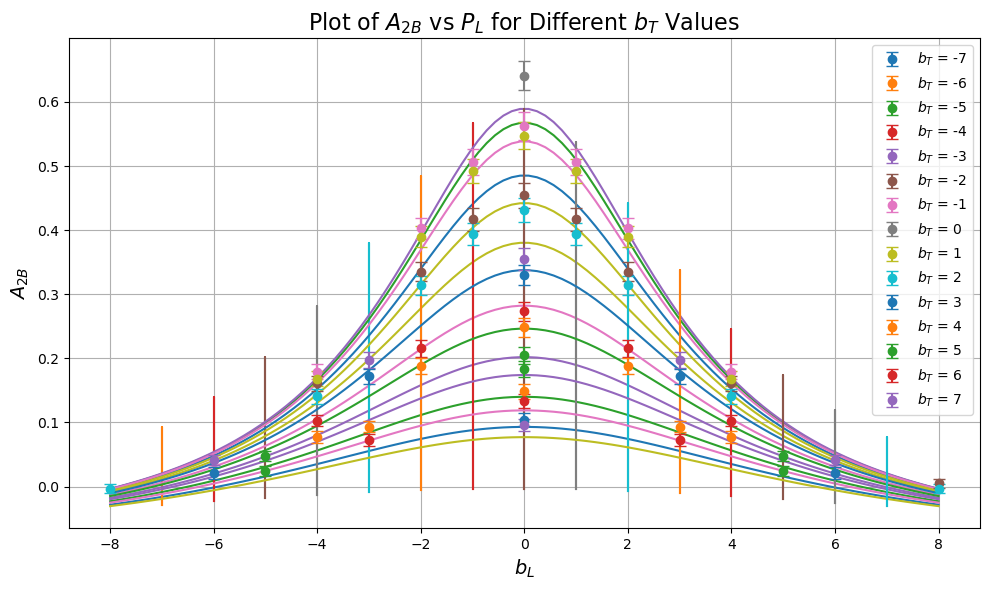

-0.09801216 - 7.014588/(bT*(bT - 1*(-0.4167135))*(-0.5753877) - (bL*bL - 1*(-10.202722)))

In [ ]:

bL_plot = np.linspace(-8,8, 100)
plt.figure(figsize=(10, 6))

for bT in unique_bT:
    bLbT_plot = np.array([[bL, bT] for bL in bL_plot])
    predictions = model.predict(bLbT_plot, pick)
    plt.plot(bLbT_plot, predictions)
for i, bT in enumerate(unique_bT):
    #if bT<1 :
    #    continue
    # Filter data for the current bT value
    mask = bLbT[:, 1] == bT
    bL_values = bLbT[mask, 0]
    A2B_values = A2B[mask]
    A2B_errors = A2Berr[mask]

    # Plot with error bars
    plt.errorbar(
        bL_values,
        A2B_values,
        yerr=A2B_errors,
        fmt='o',
        label=f"$b_T$ = {int(bT)}",
        capsize=4
    )
# Add labels, legend, and grid
plt.xlabel("$b_{L}$", fontsize=14)
plt.ylabel("$A_{2B}$", fontsize=14)
plt.title("Plot of $A_{2B}$ vs $P_L$ for Different $b_T$ Values", fontsize=16)
plt.legend(fontsize=10)
plt.grid(True)
plt.tight_layout()
plt.show()


model.sympy(pick)

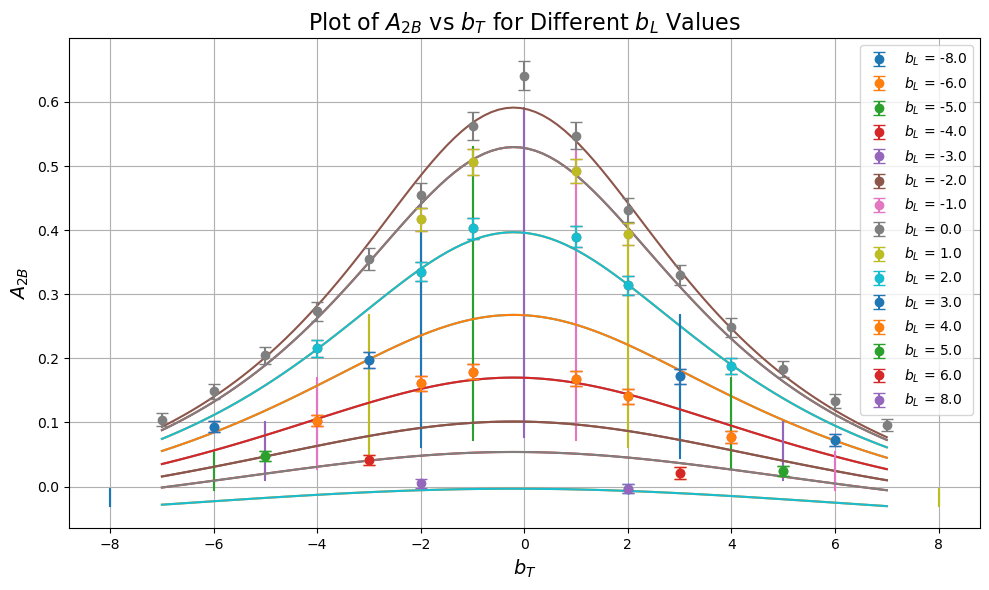

-0.09801216 - 7.014588/(bT*(bT - 1*(-0.4167135))*(-0.5753877) - (bL*bL - 1*(-10.202722)))

In [ ]:

bT_plot = np.linspace(-7,7, 100)
plt.figure(figsize=(10, 6))

for bL in unique_bL:
    bLbT_plott = np.array([[bL, bT] for bT in bT_plot])
    predictions = model.predict(bLbT_plott, pick)
    plt.plot(bLbT_plott, predictions)

for i, bL in enumerate(unique_bL):
    #if bT<1 :
    #    continue
    # Filter data for the current bT value
    mask = bLbT[:, 0] == bL
    bT_values = bLbT[mask, 1]
    A2B_values = A2B[mask]
    A2B_errors = A2Berr[mask]

    # Plot with error bars
    plt.errorbar(
        bT_values,
        A2B_values,
        yerr=A2B_errors,
        fmt='o',
        label=f"$b_L$ = {bL}",
        capsize=4
    )
# Add labels, legend, and grid
plt.xlabel("$b_T$", fontsize=14)
plt.ylabel("$A_{2B}$", fontsize=14)
plt.title("Plot of $A_{2B}$ vs $b_T$ for Different $b_L$ Values", fontsize=16)
plt.legend(fontsize=10)
plt.grid(True)
plt.tight_layout()
plt.show()

model.sympy(pick)


In [ ]:
model.equations_[["complexity", "loss", "equation"]]

,complexity,loss,equation
0,1,3496.224600,0.011494168
1,5,2694.088600,(0.04454696 ^ bT) ^ bT
2,6,2561.390900,sin((0.044563945 ^ bT) ^ bT)
3,7,2124.244400,0.051070243 / ((bT * bT) + 0.08197257)
4,9,2102.989500,0.048363578 / (((bT * bT) ^ 0.8272242) + 0.077...
5,10,847.203860,0.52314216 / ((bL * bL) + exp(bT * bT))
6,11,249.527570,0.28998753 / ((bL * bL) + ((bT * bT) + 0.41461...
7,12,7.171931,sin((((bL * bL) + (bT * bT)) + 1.2760693) ^ -1...
8,13,7.049274,(1.0949587 / ((bT * bT) + ((bL * bL) + 1.45352...
9,14,1.363645,sin(((bL * (bL * 0.87349325)) + ((bT * bT) + 1...
